# 03 — INT Group Analysis

## Objective

This notebook investigates whether regional intrinsic neural timescale (INT) measurements differ across four diagnostic groups:

- Cognitively Normal (CN)
- Mild Cognitive Impairment (MCI)
- Converter
- Alzheimer's Disease (AD)

The analysis will focus on region-level group differences before any predictive modeling is performed.

The main goals are to:

1. Combine the harmonized INT measurements with participant diagnostic labels.
2. Compare INT values across the four diagnostic groups.
3. Identify brain regions with the largest group differences.
4. Visualize INT patterns across diagnosis.
5. Perform region-level statistical testing.
6. Determine whether Converters resemble stable MCI or AD more closely.

In [6]:
# ============================================================
# Step 1: Load packages
# ============================================================

library(tidyverse)
library(janitor)
library(broom)

In [7]:
# ============================================================
# Step 2: Load INT and cortical thickness workspace
# ============================================================

load("../Data/ADNI_INT_CT_demo.RData")

In [8]:
# ============================================================
# Step 3: Add anatomical ROI labels to INT matrix
# ============================================================

rownames(intmap_combat) <- label_ROI$LabelName

dim(intmap_combat)
head(rownames(intmap_combat))

[1]  84 904

[1] "Left-Thalamus"    "Left-Caudate"     "Left-Putamen"     "Left-Pallidum"   
[5] "Left-Hippocampus" "Left-Amygdala"

# Step 4: Create the Analysis Dataset

The INT measurements are currently stored as an 84 × 904 matrix, where:

- Rows represent brain regions.
- Columns represent participants.

For statistical analyses, it is more convenient to organize the data so that:

- Each row represents one participant.
- Each column represents one INT region.
- Diagnostic information is included for every participant.

This creates a single analysis dataset that will be used throughout the remainder of this notebook.

In [9]:
# ============================================================
# Step 4: Create participant-level INT analysis dataset
# ============================================================

# Transpose the INT matrix
int_df <- as.data.frame(t(intmap_combat))

# Add subject identifier
int_df$subject <- gsub("^X", "", rownames(int_df))

# Merge with participant information
int_analysis <- baseline_demo %>%
  inner_join(int_df, by = "subject")

# Check dimensions
dim(int_analysis)

# First few variables
head(int_analysis[, 1:10])

[1] 904 112

subject,PTID,scandate,RID,SITEID,E4_combine,E4_3grp,APOE4,PTGENDER,PTDOBMM
<chr>,<chr>,<chr>,<dbl>,<fct>,<dbl>,<chr>,<chr>,<fct>,<dbl>
002S0295X20110602,002S0295,6/2/2011,295,1,34,e4,P,M,6
002S0413X20110616,002S0413,6/16/2011,413,1,33,33,N,F,12
002S0685X20110708,002S0685,7/8/2011,685,1,33,33,N,F,11
002S0729X20110816,002S0729,8/16/2011,729,1,34,e4,P,F,5
002S1155X20111222,002S1155,12/22/2011,1155,1,33,33,N,M,1
002S1261X20110314,002S1261,3/14/2011,1261,1,33,33,N,F,12


In [10]:
head(baseline_demo$subject)

head(colnames(intmap_combat))

[1] "002S0295X20110602" "002S0413X20110616" "002S0685X20110708"
[4] "002S0729X20110816" "002S1155X20111222" "002S1261X20110314"

[1] "X002S0295X20110602" "X002S0413X20110616" "X002S0685X20110708"
[4] "X002S0729X20110816" "X002S1155X20111222" "X002S1261X20110314"

# Step 5: Verify Diagnostic Groups

Before performing any statistical analyses, we verify the diagnostic grouping used throughout this notebook.

Several diagnosis-related variables exist in the dataset (e.g., `DX.new`, `ad_status`, and `group`). Based on previous analyses and discussions, the `group` variable contains the desired four diagnostic categories:

- CN
- MCI
- Converter
- AD

These four groups will serve as the primary outcome throughout the remainder of this notebook.

In [11]:
# ============================================================
# Step 5: Verify diagnostic groups
# ============================================================

table(int_analysis$group)

prop.table(table(int_analysis$group))


       CN       MCI Converter        AD 
      476       262        57       109 


       CN       MCI Converter        AD 
0.5265487 0.2898230 0.0630531 0.1205752 

# Step 6: Compare Mean INT Across Diagnostic Groups

The next objective is to investigate whether intrinsic neural timescales (INT) differ across the four diagnostic groups.

Rather than considering the overall distribution of INT values, we now calculate the average INT within each brain region separately for:

- Cognitively Normal (CN)
- Mild Cognitive Impairment (MCI)
- Converter
- Alzheimer's Disease (AD)

These summaries provide an initial look at whether functional brain dynamics change as Alzheimer's disease progresses.

This exploratory analysis will help identify candidate brain regions that may contribute to future predictive models.

In [12]:
# ============================================================
# Step 6.1
# Identify INT feature columns
# ============================================================

int_columns <- names(int_analysis)[29:112]

length(int_columns)

head(int_columns)

tail(int_columns)

[1] 84

[1] "Left-Thalamus"    "Left-Caudate"     "Left-Putamen"     "Left-Pallidum"   
[5] "Left-Hippocampus" "Left-Amygdala"

[1] "ctx-rh-superiortemporal"   "ctx-rh-supramarginal"     
[3] "ctx-rh-frontalpole"        "ctx-rh-temporalpole"      
[5] "ctx-rh-transversetemporal" "ctx-rh-insula"

In [13]:
# ============================================================
# Step 6.2
# Mean INT by diagnostic group
# ============================================================

group_means <- int_analysis %>%
  group_by(group) %>%
  summarise(across(all_of(int_columns),
                   mean,
                   na.rm = TRUE))

group_means

Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `across(all_of(int_columns), mean, na.rm = TRUE)`.
ℹ In group 1: `group = CN`.
Caused by warning:
! The `...` argument of `across()` is deprecated as of dplyr 1.1.0.
Supply arguments directly to `.fns` through an anonymous function instead.

  # Previously
  across(a:b, mean, na.rm = TRUE)

  # Now
  across(a:b, \(x) mean(x, na.rm = TRUE))”


group,Left-Thalamus,Left-Caudate,Left-Putamen,Left-Pallidum,Left-Hippocampus,Left-Amygdala,Left-Accumbens-area,Left-VentralDC,Right-Thalamus,⋯,ctx-rh-rostralanteriorcingulate,ctx-rh-rostralmiddlefrontal,ctx-rh-superiorfrontal,ctx-rh-superiorparietal,ctx-rh-superiortemporal,ctx-rh-supramarginal,ctx-rh-frontalpole,ctx-rh-temporalpole,ctx-rh-transversetemporal,ctx-rh-insula
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CN,1.504443,1.519092,1.514976,1.448821,1.492239,1.526564,1.501804,1.435700,1.508346,⋯,1.588012,1.900295,1.735374,1.904839,1.709880,1.872498,2.009664,1.592950,1.559239,1.533177
MCI,1.502055,1.507830,1.505334,1.447825,1.483238,1.510534,1.491641,1.425517,1.503076,⋯,1.588823,1.875592,1.714173,1.861513,1.682985,1.830337,1.989842,1.611790,1.548700,1.519530
Converter,1.525337,1.568170,1.545119,1.482291,1.516550,1.537719,1.514956,1.432440,1.534530,⋯,1.594934,1.935191,1.775830,1.933390,1.749489,1.859978,2.053865,1.649996,1.593497,1.524594
AD,1.523134,1.538184,1.545326,1.473613,1.506363,1.538271,1.514026,1.435305,1.535359,⋯,1.584928,1.893128,1.737296,1.891601,1.735395,1.856058,1.991415,1.659647,1.569904,1.535112


# Step 7: Identify Brain Regions with the Largest Group Differences

The previous table summarizes the average INT value for every brain region within each diagnostic group.

Rather than inspecting all 84 regions individually, we compute the range of the group means for each region:

Range = Maximum group mean − Minimum group mean

Regions with larger ranges exhibit greater differences in INT across the four diagnostic groups and may represent candidate biomarkers for disease progression.

In [14]:
# ============================================================
# Step 7
# Rank brain regions by group differences
# ============================================================

group_range <- data.frame(

  Region = int_columns,

  Range = sapply(int_columns, function(region){

    means <- group_means[[region]]

    max(means) - min(means)

  })

)

group_range <- group_range %>%
  arrange(desc(Range))

head(group_range, 15)

,Region,Range
,<chr>,<dbl>
ctx-rh-pericalcarine,ctx-rh-pericalcarine,0.10904975
ctx-rh-bankssts,ctx-rh-bankssts,0.09081883
ctx-lh-parstriangularis,ctx-lh-parstriangularis,0.08698850
ctx-lh-inferiortemporal,ctx-lh-inferiortemporal,0.07862548
ctx-rh-entorhinal,ctx-rh-entorhinal,0.07642750
ctx-rh-inferiortemporal,ctx-rh-inferiortemporal,0.07469016
ctx-rh-parsorbitalis,ctx-rh-parsorbitalis,0.07326821
ctx-lh-caudalanteriorcingulate,ctx-lh-caudalanteriorcingulate,0.07219737
ctx-lh-lingual,ctx-lh-lingual,0.07207529


## Interpretation

The regions with the largest INT differences across diagnostic groups are not identical to those identified using cortical thickness.

This is expected because cortical thickness measures structural atrophy, whereas intrinsic neural timescales (INT) measure functional brain dynamics.

Although several temporal regions (e.g., entorhinal, inferior temporal, fusiform) remain among the highest-ranking regions, the ordering differs from the structural analysis. This suggests that INT may capture complementary information about Alzheimer's disease progression beyond cortical atrophy.

Because these rankings are based solely on differences in group means, formal statistical testing is required to determine whether the observed differences are statistically significant.

# Step 8: Statistical Comparison of INT Across Diagnostic Groups

The previous analysis ranked brain regions according to differences in their average intrinsic neural timescales (INT) across the four diagnostic groups.

However, differences in group means alone do not indicate whether those differences are statistically meaningful.

To formally test whether INT differs across diagnostic groups, we perform a one-way Analysis of Variance (ANOVA) independently for each of the 84 brain regions.

For each region, the hypotheses are:

- **Null hypothesis (H₀):** All four diagnostic groups have the same mean INT.
- **Alternative hypothesis (H₁):** At least one diagnostic group has a different mean INT.

Regions with small p-values provide evidence that INT differs across disease stages and may represent candidate biomarkers for Alzheimer's disease progression.

In [15]:
# ============================================================
# Step 8.1
# One-way ANOVA for every INT region
# ============================================================

anova_results <- lapply(int_columns, function(region){

  formula <- as.formula(paste0("`", region, "` ~ group"))

  fit <- aov(formula, data = int_analysis)

  p_value <- summary(fit)[[1]][["Pr(>F)"]][1]

  F_value <- summary(fit)[[1]][["F value"]][1]

  data.frame(

    Region = region,

    F_statistic = F_value,

    P_value = p_value

  )

})

anova_results <- do.call(rbind, anova_results)

In [16]:
# ============================================================
# Step 8.2
# Rank regions by statistical significance
# ============================================================

anova_results <- anova_results %>%
  arrange(P_value)

head(anova_results, 15)

,Region,F_statistic,P_value
,<chr>,<dbl>,<dbl>
1,ctx-lh-inferiortemporal,6.957940,0.0001246349
2,ctx-rh-entorhinal,6.641709,0.0001941204
3,Right-Caudate,6.069018,0.0004325317
4,Right-Pallidum,5.797254,0.0006321645
5,ctx-rh-inferiortemporal,5.563850,0.0008753726
6,ctx-rh-fusiform,5.392207,0.0011117991
7,ctx-lh-fusiform,5.298166,0.0012672643
8,Left-Caudate,4.923861,0.0021317128
9,ctx-rh-temporalpole,4.292264,0.0051071924


In [17]:
# ============================================================
# Step 8.3
# Number of significant regions
# ============================================================

sum(anova_results$P_value < 0.05)

nrow(anova_results)

[1] 26

[1] 84

## Interpretation

One-way ANOVA identified **26 of the 84 INT regions** with statistically significant differences across the four diagnostic groups (p < 0.05).

Several of the most significant regions—including the entorhinal cortex, fusiform cortex, inferior temporal cortex, and superior temporal cortex—are well-established brain regions affected during Alzheimer's disease progression.

Interestingly, several subcortical structures (caudate, putamen, and pallidum) also demonstrated significant differences. These regions were less prominent in the cortical thickness analysis, suggesting that intrinsic neural timescales may capture functional alterations that complement structural MRI measurements.

These results provide evidence that INT contains disease-related information and motivate further investigation using predictive modeling.

# Step 9: Visualize Significant INT Regions

The ANOVA identified several brain regions whose intrinsic neural timescales (INT) differed significantly across the four diagnostic groups.

To better understand these differences, we visualize the distribution of INT values for the most significant regions using boxplots.

Unlike summary statistics alone, boxplots display:

- the median INT
- the spread of each group
- potential outliers
- overlap between diagnostic groups

These visualizations help determine whether disease progression follows a gradual trend or whether Converters more closely resemble Alzheimer's disease, providing insight into the biological interpretation of the statistical results.

In [18]:
# ============================================================
# Step 9.1
# Select the six most significant INT regions
# ============================================================

top_regions <- anova_results$Region[1:6]

top_regions

[1] "ctx-lh-inferiortemporal" "ctx-rh-entorhinal"      
[3] "Right-Caudate"           "Right-Pallidum"         
[5] "ctx-rh-inferiortemporal" "ctx-rh-fusiform"

In [19]:
library(tidyr)
library(ggplot2)

In [20]:
# ============================================================
# Step 9.2
# Reshape data for plotting
# ============================================================

plot_data <- int_analysis %>%
  select(group, all_of(top_regions)) %>%
  pivot_longer(
    cols = -group,
    names_to = "Region",
    values_to = "INT"
  )

head(plot_data)

group,Region,INT
<fct>,<chr>,<dbl>
CN,ctx-lh-inferiortemporal,1.525592
CN,ctx-rh-entorhinal,1.402408
CN,Right-Caudate,1.418418
CN,Right-Pallidum,1.417143
CN,ctx-rh-inferiortemporal,1.738312
CN,ctx-rh-fusiform,1.624587


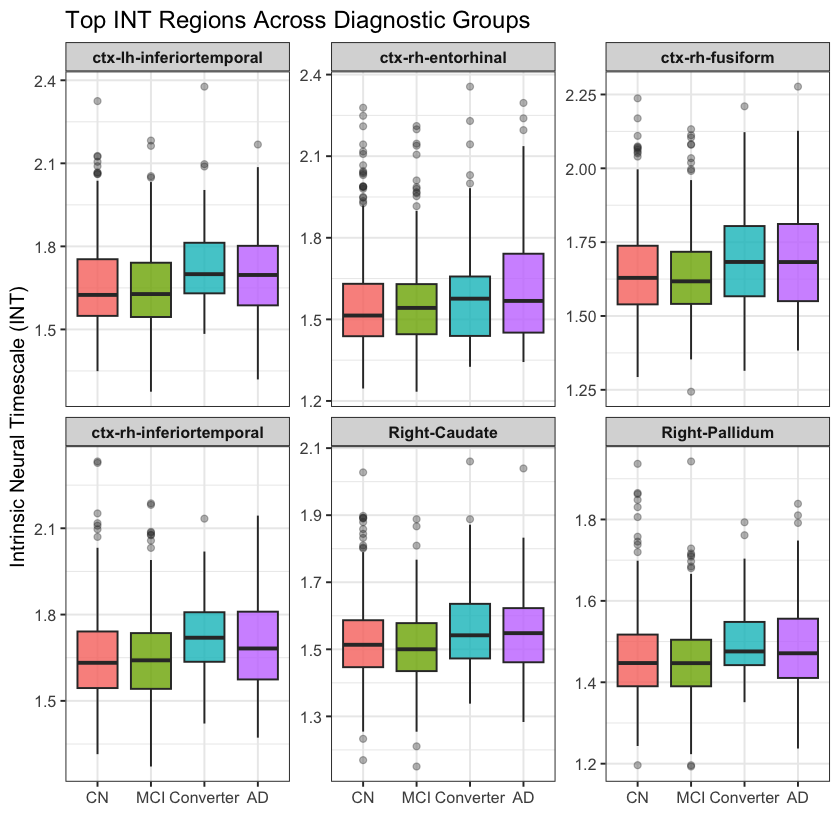

In [21]:
# ============================================================
# Step 9.3
# Boxplots of significant INT regions
# ============================================================

ggplot(plot_data,
       aes(x = group,
           y = INT,
           fill = group)) +

  geom_boxplot(alpha = 0.8,
               outlier.alpha = 0.35) +

  facet_wrap(~Region,
             scales = "free_y") +

  theme_bw(base_size = 12) +

  labs(
    title = "Top INT Regions Across Diagnostic Groups",
    x = "",
    y = "Intrinsic Neural Timescale (INT)"
  ) +

  theme(
    legend.position = "none",
    strip.text = element_text(face = "bold")
  )

## Interpretation of the Top INT Regions

Visualization of the six most significant INT regions reveals a consistent pattern across diagnostic groups.

For several regions—including the inferior temporal cortex, fusiform cortex, caudate, pallidum, and entorhinal cortex—the CN and MCI groups exhibit highly overlapping INT distributions. In contrast, the Converter and AD groups tend to display higher INT values and appear more similar to one another.

Rather than observing a gradual monotonic progression (CN → MCI → Converter → AD), these results suggest that functional brain dynamics may shift earlier in individuals who will eventually convert to Alzheimer's disease.

This observation is consistent with our original hypothesis that Converters may already exhibit Alzheimer's-like functional characteristics prior to clinical diagnosis.

# Step 10: Post-hoc Pairwise Comparisons

One-way ANOVA determines whether at least one diagnostic group differs from the others, but it does not identify which specific groups are different.

To determine where these differences occur, we perform Tukey's Honest Significant Difference (HSD) test for the most significant INT regions.

The primary biological question is whether Converters are statistically more similar to Alzheimer's disease (AD) than to Mild Cognitive Impairment (MCI), which would support the hypothesis that functional brain changes occur before a clinical diagnosis of Alzheimer's disease.

In [22]:
anova_results[1,]

,Region,F_statistic,P_value
,<chr>,<dbl>,<dbl>
1,ctx-lh-inferiortemporal,6.95794,0.0001246349


In [23]:
# ===========================================
# Step 10.1
# Tukey HSD for the most significant region
# ===========================================

fit <- aov(`ctx-lh-inferiortemporal` ~ group,
           data = int_analysis)

tukey <- TukeyHSD(fit)

tukey

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = `ctx-lh-inferiortemporal` ~ group, data = int_analysis)

$group
                      diff          lwr        upr     p adj
MCI-CN        -0.006214811 -0.036577236 0.02414761 0.9525926
Converter-CN   0.072410669  0.017090296 0.12773104 0.0043670
AD-CN          0.047633552  0.005722979 0.08954413 0.0184876
Converter-MCI  0.078625480  0.020939581 0.13631138 0.0026642
AD-MCI         0.053848363  0.008861526 0.09883520 0.0114110
AD-Converter  -0.024777117 -0.089292869 0.03973864 0.7560635


In [24]:
tukey_df <- as.data.frame(tukey$group)

tukey_df$Comparison <- rownames(tukey_df)

rownames(tukey_df) <- NULL

tukey_df

diff,lwr,upr,p adj,Comparison
<dbl>,<dbl>,<dbl>,<dbl>,<chr>
-0.006214811,-0.036577236,0.02414761,0.952592571,MCI-CN
0.072410669,0.017090296,0.12773104,0.004366989,Converter-CN
0.047633552,0.005722979,0.08954413,0.018487615,AD-CN
0.078625480,0.020939581,0.13631138,0.002664240,Converter-MCI
0.053848363,0.008861526,0.09883520,0.011411000,AD-MCI
-0.024777117,-0.089292869,0.03973864,0.756063522,AD-Converter


### Interpretation
To better understand the significant ANOVA results, a post-hoc Tukey HSD test was performed on the most significant INT regions. For the left inferior temporal cortex, both the Converter and AD groups showed significantly higher INT values than the CN and MCI groups. However, there was no significant difference between the Converter and AD groups (adjusted p = 0.756). This suggests that baseline INT measurements in this region already resemble the Alzheimer's disease group prior to clinical conversion, supporting the hypothesis that Converters may exhibit AD-like functional brain dynamics before diagnosis.

# Step 9: Prepare INT Data for Machine Learning

The next objective is to determine whether the 84 regional INT measurements can classify participants into the four diagnostic groups: CN, MCI, Converter, and AD.

For this analysis, the modeling dataset contains only:

- `group` as the outcome variable
- the 84 regional INT measurements as predictors

Participant identifiers, demographic variables, and other clinical information are excluded so that this model evaluates the predictive value of INT alone.

In [27]:
# ============================================================
# Step 9.1: Create INT-only modeling dataset
# ============================================================

model_data_INT <- int_analysis %>%
  select(
    group,
    all_of(int_columns)
  )

# Verify dimensions
dim(model_data_INT)

# Verify outcome and predictor structure
glimpse(model_data_INT)

[1] 904  85

Rows: 904
Columns: 85
$ group                             <fct> CN, CN, CN, AD, MCI, CN, Converter, …
$ `Left-Thalamus`                   <dbl> 1.512157, 1.430923, 1.431114, 1.8990…
$ `Left-Caudate`                    <dbl> 1.538652, 1.413411, 1.421197, 1.5573…
$ `Left-Putamen`                    <dbl> 1.698980, 1.398419, 1.451034, 1.6498…
$ `Left-Pallidum`                   <dbl> 1.414463, 1.371094, 1.511608, 1.5818…
$ `Left-Hippocampus`                <dbl> 1.473932, 1.276016, 1.315995, 1.4332…
$ `Left-Amygdala`                   <dbl> 1.503231, 1.198950, 1.490184, 1.4887…
$ `Left-Accumbens-area`             <dbl> 1.408640, 1.483999, 1.356995, 1.5022…
$ `Left-VentralDC`                  <dbl> 1.478294, 1.314886, 1.344563, 1.3508…
$ `Right-Thalamus`                  <dbl> 1.513037, 1.375979, 1.354460, 1.6853…
$ `Right-Caudate`                   <dbl> 1.418418, 1.365113, 1.539083, 1.5616…
$ `Right-Putamen`                   <dbl> 1.499597, 1.369009, 1.442891, 1.6090…
$ `Right-Pallidum`

In [28]:
# ============================================================
# Step 9.2: Check missing values
# ============================================================

missing_by_column <- colSums(is.na(model_data_INT))

# Show columns containing missing values
missing_by_column[missing_by_column > 0]

# Total number of missing values
sum(is.na(model_data_INT))

Left-Accumbens-area               ctx-lh-entorhinal 
                              1                               1 
         ctx-lh-parahippocampal ctx-rh-rostralanteriorcingulate 
                              1                               1

[1] 4

In [29]:
# ============================================================
# Step 9.3: Remove rows with incomplete INT measurements
# ============================================================

model_data_INT_complete <- model_data_INT %>%
  drop_na()

# Check dimensions after removing incomplete rows
dim(model_data_INT_complete)

# Number of participants removed
nrow(model_data_INT) - nrow(model_data_INT_complete)

[1] 901  85

[1] 3

In [30]:
# ============================================================
# Step 9.4: Verify class balance after removing missing values
# ============================================================

model_data_INT_complete %>%
  count(group)

prop.table(
  table(model_data_INT_complete$group)
)

group,n
<fct>,<int>
CN,476
MCI,260
Converter,57
AD,108



        CN        MCI  Converter         AD 
0.52830189 0.28856826 0.06326304 0.11986681 

# Step 11: Create a Stratified Train/Test Split

To evaluate whether regional INT measurements can predict diagnostic group membership, the complete-case dataset is divided into separate training and testing subsets.

A stratified 80%/20% split is used so that the proportions of CN, MCI, Converter, and AD participants remain approximately consistent across both subsets.

The training set will be used for cross-validation and model fitting, while the held-out testing set will remain unseen until final model evaluation.

In [31]:
# ============================================================
# Step 11.1: Create stratified 80/20 train-test split
# ============================================================

library(caret)

set.seed(123)

train_index_INT <- createDataPartition(
  model_data_INT_complete$group,
  p = 0.80,
  list = FALSE
)

train_INT <- model_data_INT_complete[train_index_INT, ]
test_INT  <- model_data_INT_complete[-train_index_INT, ]

# Check dimensions
dim(train_INT)
dim(test_INT)

[1] 722  85

[1] 179  85

In [32]:
# ============================================================
# Step 11.2: Verify class balance in each subset
# ============================================================

train_INT %>%
  count(group)

test_INT %>%
  count(group)

prop.table(table(train_INT$group))
prop.table(table(test_INT$group))

group,n
<fct>,<int>
CN,381
MCI,208
Converter,46
AD,87


group,n
<fct>,<int>
CN,95
MCI,52
Converter,11
AD,21



        CN        MCI  Converter         AD 
0.52770083 0.28808864 0.06371191 0.12049861 


        CN        MCI  Converter         AD 
0.53072626 0.29050279 0.06145251 0.11731844 

# Step 12: Train an INT-only Multinomial LASSO Model

The first predictive model uses only intrinsic neural timescale (INT) features as predictors.

A multinomial LASSO model is fit using the training dataset with 10-fold cross-validation to identify the optimal amount of regularization.

The outcome variable is the four-class diagnosis:

- CN
- MCI
- Converter
- AD

Model performance will later be evaluated on the held-out testing dataset.

In [33]:
library(glmnet)

# Predictor matrix
x_train_INT <- as.matrix(
  train_INT %>%
    select(-group)
)

# Response
y_train_INT <- train_INT$group

dim(x_train_INT)
table(y_train_INT)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-10



[1] 722  84

y_train_INT
       CN       MCI Converter        AD 
      381       208        46        87 

## Step 12.2: Fit the Multinomial LASSO Model

A multinomial LASSO classifier is fit using the training dataset.

The LASSO penalty shrinks less informative coefficients toward zero, allowing the model to automatically perform feature selection while reducing overfitting.

The optimal penalty parameter (λ) is selected using 10-fold cross-validation.

In [34]:
# ============================================================
# Step 12.2: Fit multinomial LASSO using 10-fold CV
# ============================================================

set.seed(123)

cv_INT <- cv.glmnet(
  x = x_train_INT,
  y = y_train_INT,
  family = "multinomial",
  alpha = 1,
  nfolds = 10
)

[1] 0.03817745

[1] 0.05538894

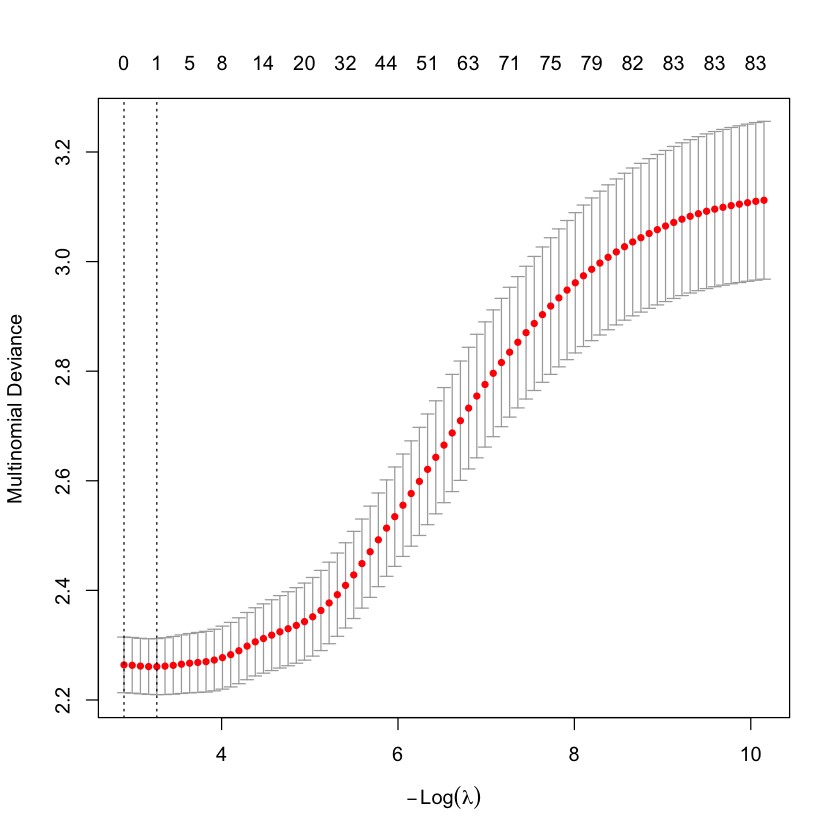

In [35]:
# Plot cross-validation curve
plot(cv_INT)

# Optimal lambda values
cv_INT$lambda.min
cv_INT$lambda.1se

In [36]:
coef_INT <- coef(cv_INT, s = "lambda.1se")

lapply(coef_INT, function(x) {
  sum(x[,1] != 0)
})

$CN
[1] 1

$MCI
[1] 1

$Converter
[1] 1

$AD
[1] 1

In [37]:
coef_INT_min <- coef(cv_INT, s = "lambda.min")

lapply(coef_INT_min, function(x){
  sum(x[,1] != 0)
})

$CN
[1] 3

$MCI
[1] 5

$Converter
[1] 1

$AD
[1] 1

### Interpretation

Using the more conservative λ₁se penalty, the multinomial LASSO removed every INT feature and retained only the intercept for each diagnostic class, suggesting that no individual INT region provided sufficient predictive value under strong regularization.

Using λmin, several INT regions were retained for the CN and MCI classes, while the Converter and AD classes still retained only the intercept. This suggests that INT measurements contain some diagnostic information but may not provide enough unique information to distinguish Converter and AD participants independently within a sparse linear model.

This observation is consistent with the hypothesis that Converters share similar neurobiological characteristics with AD participants, making them more difficult to separate using INT features alone.

In [38]:
# Predictor matrix
x_test_INT <- as.matrix(
  test_INT %>%
    select(-group)
)

# True labels
y_test_INT <- test_INT$group

# Predict classes
pred_INT <- predict(
  cv_INT,
  newx = x_test_INT,
  s = "lambda.1se",
  type = "class"
)

head(pred_INT)

lambda.1se
CN
CN
CN
CN
CN
CN


In [39]:
confusionMatrix(
  factor(pred_INT,
         levels = levels(y_test_INT)),
  y_test_INT
)

Confusion Matrix and Statistics

           Reference
Prediction  CN MCI Converter AD
  CN        95  52        11 21
  MCI        0   0         0  0
  Converter  0   0         0  0
  AD         0   0         0  0

Overall Statistics
                                          
               Accuracy : 0.5307          
                 95% CI : (0.4548, 0.6056)
    No Information Rate : 0.5307          
    P-Value [Acc > NIR] : 0.5304          
                                          
                  Kappa : 0               
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: CN Class: MCI Class: Converter Class: AD
Sensitivity             1.0000     0.0000          0.00000    0.0000
Specificity             0.0000     1.0000          1.00000    1.0000
Pos Pred Value          0.5307        NaN              NaN       NaN
Neg Pred Value             NaN     0.7095          0.93855    0.8827
Prevalence 

In [40]:
pred_INT_min <- predict(
  cv_INT,
  newx = x_test_INT,
  s = "lambda.min",
  type = "class"
)

confusionMatrix(
  factor(pred_INT_min,
         levels = levels(y_test_INT)),
  y_test_INT
)

Confusion Matrix and Statistics

           Reference
Prediction  CN MCI Converter AD
  CN        95  52        11 21
  MCI        0   0         0  0
  Converter  0   0         0  0
  AD         0   0         0  0

Overall Statistics
                                          
               Accuracy : 0.5307          
                 95% CI : (0.4548, 0.6056)
    No Information Rate : 0.5307          
    P-Value [Acc > NIR] : 0.5304          
                                          
                  Kappa : 0               
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: CN Class: MCI Class: Converter Class: AD
Sensitivity             1.0000     0.0000          0.00000    0.0000
Specificity             0.0000     1.0000          1.00000    1.0000
Pos Pred Value          0.5307        NaN              NaN       NaN
Neg Pred Value             NaN     0.7095          0.93855    0.8827
Prevalence 

### Interpretation

The INT-only multinomial LASSO model predicted every participant as cognitively normal (CN), regardless of whether λ₁se or λmin was used.

Although a small number of INT features were retained under λmin, these features were insufficient to alter the predicted class for any participant in the independent test set.

Consequently, the model achieved an accuracy of 53.1%, which equals the prevalence of the majority (CN) class. The Cohen's Kappa statistic of 0 indicates that the classifier performed no better than a majority-class baseline after accounting for chance agreement.

These findings suggest that regional INT measurements alone do not provide sufficient discriminative information for four-class diagnosis within a sparse multinomial LASSO framework.